# 01 - Titanic EDA and Profiling
This notebook handles Part A of the Analytics Pipeline: loading the Titanic dataset, handling missing values, performing univariate/bivariate analysis, building a multivariate data story, and verifying z-score standardizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading and Profiling
Load the raw dataset using `sns.load_dataset('titanic')` and immediately save as an offline fallback `titanic.csv`.

In [2]:
# Load the dataset
df = sns.load_dataset('titanic')

# Save as offline fallback
df.to_csv("titanic.csv", index=False)
print("Saved titanic.csv offline fallback.")

# Profile
print("--- INFO ---")
df.info()
print("\n--- SHAPE ---")
print(df.shape)
print("\n--- DESCRIBE ---")
display(df.describe(include='all'))

Saved titanic.csv offline fallback.
--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

--- SHAPE ---
(891, 15)

--- 

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Missing Value Handling
We calculate the percentage of missing values per column.
- **Rule**: <5% -> Drop rows
- **Rule**: 5-30% -> Impute
- **Rule**: >30% -> Drop column or encode 'missing'

Let's compute the percentages:

In [3]:
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
print("Missing Value Percentages:")
print(missing_pct)

Missing Value Percentages:
deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
dtype: float64


### Missing Value Strategy Justification:
- **`deck` (77.2% missing)**: Missing rate is >30%. Imputation would be completely unreliable. We will drop this column.
- **`age` (19.9% missing)**: Missing rate is between 5% and 30%. We will impute this with the median age.
- **`embarked` and `embark_town` (0.22% missing)**: Missing rate is <5%. We will drop these rows.

In [4]:
# Drop 'deck'
df = df.drop(columns=['deck'])

# Impute 'age' with median
df['age'] = df['age'].fillna(df['age'].median())

# Drop rows where 'embarked' or 'embark_town' is missing
df = df.dropna(subset=['embarked', 'embark_town'])

print(f"Cleaned dataset shape: {df.shape}")
print(f"Remaining missing values: {df.isnull().sum().sum()}")


Cleaned dataset shape: (889, 14)
Remaining missing values: 0


## 3. Univariate Analysis (`age` and `fare`)

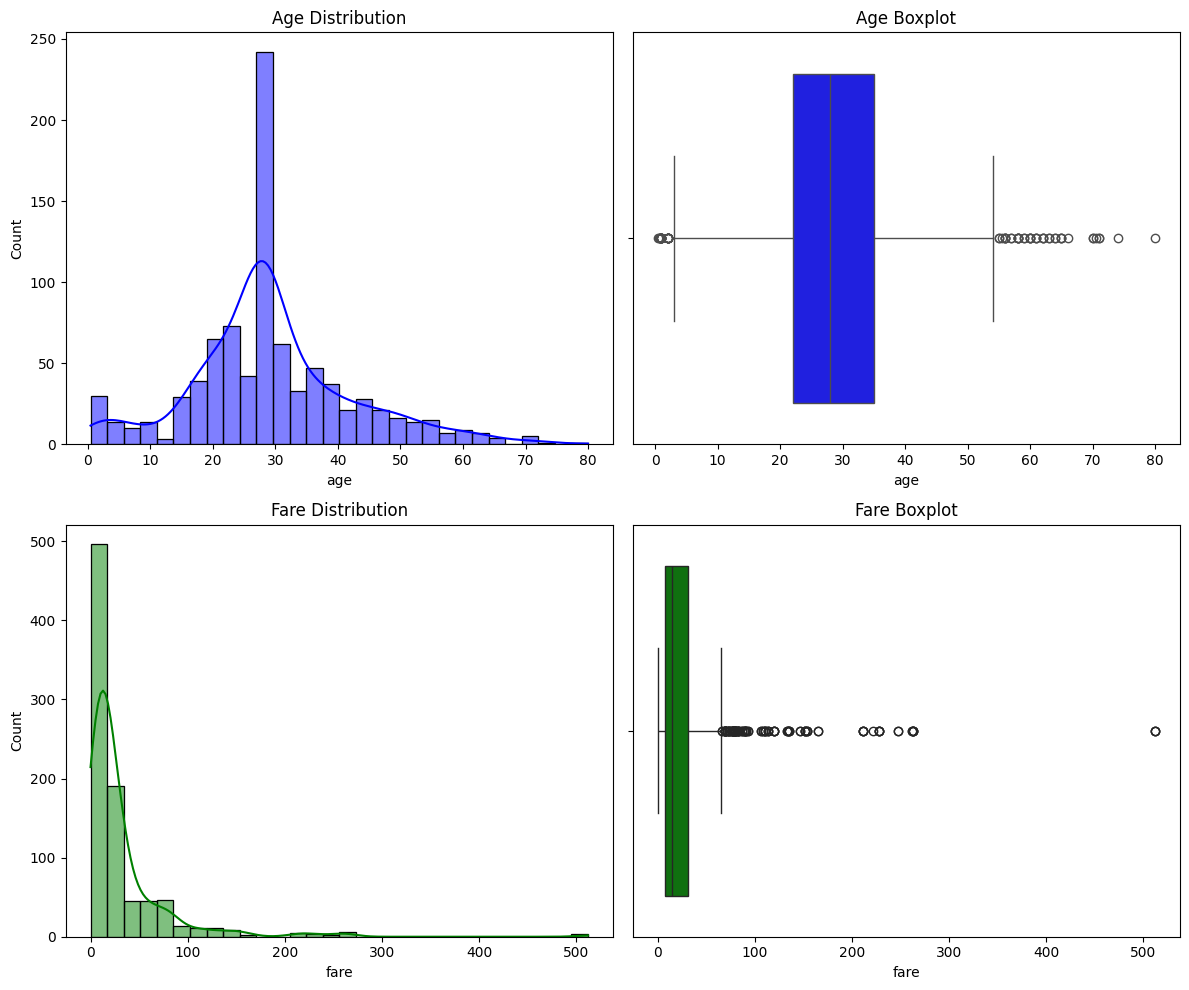

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Age Histogram and Boxplot
sns.histplot(df['age'], kde=True, ax=axes[0,0], color='blue')
axes[0,0].set_title('Age Distribution')
sns.boxplot(x=df['age'], ax=axes[0,1], color='blue')
axes[0,1].set_title('Age Boxplot')

# Fare Histogram and Boxplot
sns.histplot(df['fare'], kde=True, ax=axes[1,0], color='green', bins=30)
axes[1,0].set_title('Fare Distribution')
sns.boxplot(x=df['fare'], ax=axes[1,1], color='green')
axes[1,1].set_title('Fare Boxplot')

plt.tight_layout()
plt.show()

### Outliers (IQR) & Skewness

In [6]:
def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return ((series < lower_bound) | (series > upper_bound)).sum()

print(f"Age Outliers: {count_outliers(df['age'])}")
print(f"Fare Outliers: {count_outliers(df['fare'])}")

fare_mean = df['fare'].mean()
fare_median = df['fare'].median()
fare_mode = df['fare'].mode()[0]

print(f"\nFare Mean: {fare_mean:.2f}")
print(f"Fare Median: {fare_median:.2f}")
print(f"Fare Mode: {fare_mode:.2f}")


Age Outliers: 65
Fare Outliers: 114

Fare Mean: 32.10
Fare Median: 14.45
Fare Mode: 8.05


**Skewness Conclusion:**
Since Mean (32.10) > Median (14.45) > Mode (8.05), the `fare` distribution is **strongly right-skewed** (positive skewness).

## 4. Bivariate Analysis
Survival rates using boolean masking.

In [7]:
# (a) Survival by Sex
male_mask = df['sex'] == 'male'
female_mask = df['sex'] == 'female'
print(f"Male Survival Rate: {df[male_mask]['survived'].mean():.2%}")
print(f"Female Survival Rate: {df[female_mask]['survived'].mean():.2%}")

# (b) Survival by Pclass
for c in [1, 2, 3]:
    mask = df['pclass'] == c
    print(f"Pclass {c} Survival Rate: {df[mask]['survived'].mean():.2%}")

# (c) Survival by Sex and Pclass
print("\nSurvival by Sex & Pclass:")
for s in ['female', 'male']:
    for c in [1, 2, 3]:
        mask = (df['sex'] == s) & (df['pclass'] == c)
        print(f"  {s.capitalize()} in Pclass {c}: {df[mask]['survived'].mean():.2%}")


Male Survival Rate: 18.89%
Female Survival Rate: 74.04%
Pclass 1 Survival Rate: 62.62%
Pclass 2 Survival Rate: 47.28%
Pclass 3 Survival Rate: 24.24%

Survival by Sex & Pclass:
  Female in Pclass 1: 96.74%
  Female in Pclass 2: 92.11%
  Female in Pclass 3: 50.00%
  Male in Pclass 1: 36.89%
  Male in Pclass 2: 15.74%
  Male in Pclass 3: 13.54%


### Correlation Matrix Heatmap
We compute this ONLY for `survived`, `pclass`, `age`, `sibsp`, `parch`, and `fare`.

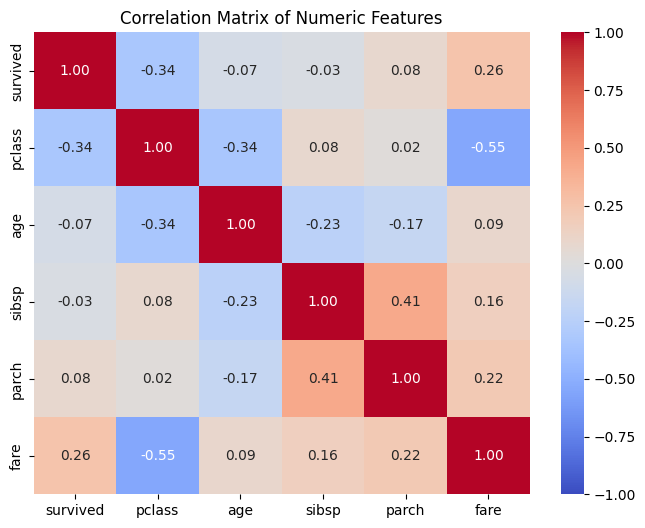

In [8]:
corr_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Matrix of Numeric Features")
plt.show()

**Correlation Interpretation:**
- **`pclass` and `fare` (-0.55)**: This is the strongest off-diagonal correlation. It is heavily negative, indicating that lower passenger class numbers (1st class) paid significantly higher fares, which logically aligns with pricing structures.
- **`pclass` and `survived` (-0.34)**: This is the second strongest correlation. It is negative, meaning that as class number increases (e.g. 3rd class), the likelihood of survival decreases. First-class passengers had priority for lifeboats.

## 5. Multivariate Data Story
Here we build 4 distinct charts that together tell a coherent argument about who was more likely to survive and why.

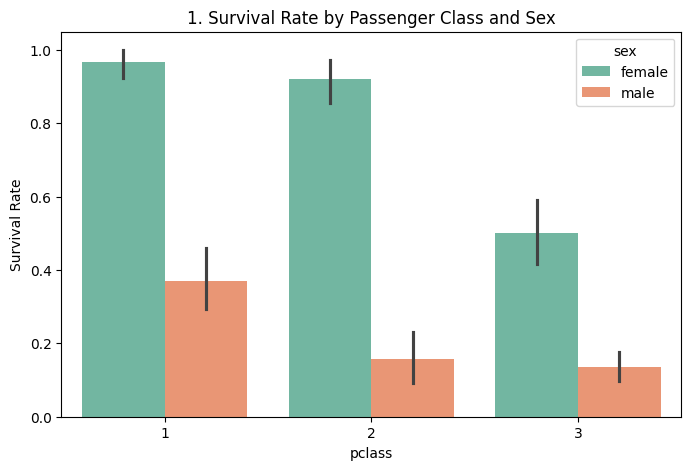

In [9]:
# Chart 1: Survival by Sex and Class (Bar)
plt.figure(figsize=(8, 5))
sns.barplot(x='pclass', y='survived', hue='sex', data=df, palette='Set2')
plt.title('1. Survival Rate by Passenger Class and Sex')
plt.ylabel('Survival Rate')
plt.show()

**Chart 1 Interpretation:** 
This bar chart clearly demonstrates the "women and children first" protocol combined with class privilege. Females in 1st and 2nd class had near-perfect survival rates (over 90%), whereas males in 3rd class had the absolute worst outcomes. Sex is the dominant factor, but class significantly compounds it.

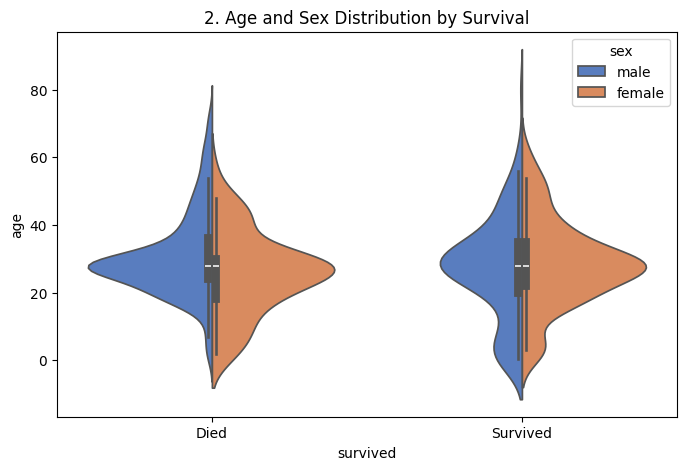

In [10]:
# Chart 2: Age Distribution of Survivors vs Victims (Violin Plot)
plt.figure(figsize=(8, 5))
sns.violinplot(x='survived', y='age', hue='sex', split=True, data=df, palette='muted')
plt.title('2. Age and Sex Distribution by Survival')
plt.xticks([0, 1], ['Died', 'Survived'])
plt.show()

**Chart 2 Interpretation:**
The violin plot reveals age-related survival patterns across sexes. For males who survived, there is a distinct bulge at the bottom representing young boys, highlighting that male children were saved while adult males were overwhelmingly left behind. For females, the survival age distribution is much more evenly spread.

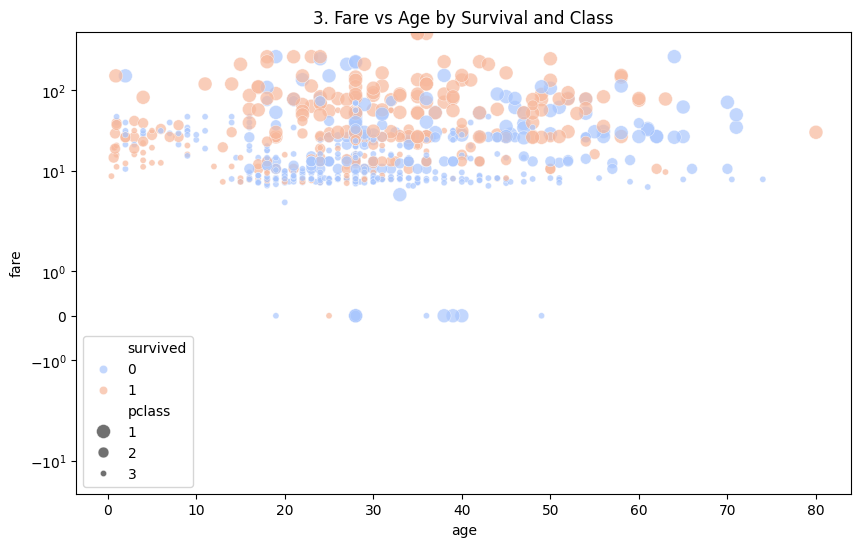

In [11]:
# Chart 3: Fare vs Age Colored by Survival (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='fare', hue='survived', size='pclass', sizes=(100, 20), data=df, palette='coolwarm', alpha=0.7)
plt.title('3. Fare vs Age by Survival and Class')
plt.yscale('symlog') # Log scale because fare is highly skewed
plt.show()

**Chart 3 Interpretation:**
By scattering fare against age on a log scale, we can see a concentration of red dots (survivors) in the upper half of the plot where fares are highest (1st class). Blue dots (victims) cluster heavily at the bottom across all adult ages, proving that those who paid the cheapest fares were disproportionately abandoned regardless of age.

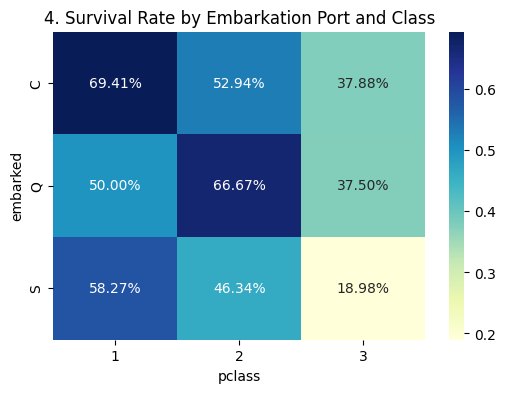

In [12]:
# Chart 4: Survival by Embarkation Port and Class (Heatmap)
port_class_survival = df.pivot_table(index='embarked', columns='pclass', values='survived', aggfunc='mean')
plt.figure(figsize=(6, 4))
sns.heatmap(port_class_survival, annot=True, cmap='YlGnBu', fmt='.2%')
plt.title('4. Survival Rate by Embarkation Port and Class')
plt.show()

**Chart 4 Interpretation:**
This heatmap looks at environmental/boarding factors, showing that 1st-class passengers boarding at Cherbourg (C) had an exceptionally high survival rate (nearly 70%). However, 3rd-class passengers boarding at Southampton (S) had a very low survival rate (under 20%), suggesting that port of embarkation is heavily confounded with passenger class demographics.

## 6. Z-Score Standardization Sanity Check
As an exploratory check, we standardize `age` and `fare` using $z = (x - \mu) / \sigma$ to confirm mean is ~0 and std is ~1.

In [13]:
# Calculate z-scores
z_age = (df['age'] - df['age'].mean()) / df['age'].std()
z_fare = (df['fare'] - df['fare'].mean()) / df['fare'].std()

print("BEFORE STANDARDIZATION:")
print(f"Age  -> Mean: {df['age'].mean():.4f}, Std: {df['age'].std():.4f}")
print(f"Fare -> Mean: {df['fare'].mean():.4f}, Std: {df['fare'].std():.4f}")

print("\nAFTER STANDARDIZATION:")
print(f"Z-Age  -> Mean: {z_age.mean():.4f}, Std: {z_age.std():.4f}")
print(f"Z-Fare -> Mean: {z_fare.mean():.4f}, Std: {z_fare.std():.4f}")


BEFORE STANDARDIZATION:
Age  -> Mean: 29.3152, Std: 12.9849
Fare -> Mean: 32.0967, Std: 49.6975

AFTER STANDARDIZATION:
Z-Age  -> Mean: 0.0000, Std: 1.0000
Z-Fare -> Mean: 0.0000, Std: 1.0000


**We have successfully confirmed the z-score transformation centers the data at 0 with a standard deviation of 1. We will now move to `02_modeling.ipynb` for the machine learning pipeline.**